---
**Name : Aashoday S Surwade**\
**Roll No : 24AI126**\
**Class : SE-B AIML**\
**Course : FML**\
**FML Assignment 1**

---

**Problem Statement** :

Implement assignment based on implementation of Supervised
and Unsupervised Machine Learning Techniques using Python
(scikit-learn)

*Case Study* : Customer Segmentation for a Retail Store : A retail
company wants to segment its customers based on purchasing
behavior to tailor marketing strategies.

---

In [1]:
# Import Libraries

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

from sklearn.cluster import KMeans


In [2]:
# Load Dataset
df = pd.read_csv("/home/ashx/ML/Projects/fml-lab/data/Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


---
### Part 1 - Supervised Learning 

---

In [3]:
# Generate labels
# 0 -> Low Spender
# 1 -> High Spender

df["Spending_Category"] = (df["Spending Score (1-100)"] > 50).astype(int)

In [4]:
# Select Features and target

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]    # Features
y = df["Spending_Category"]                                 # Target

In [5]:
# Feature Scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
# Split data in training and testing sets
RANDOM_SEED = 911

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_SEED
)

print(f"Shapes: X_train: {X_train.shape} | X_test: {X_test.shape} | y_train: {y_train.shape} | y_test: {y_test.shape} ")

Shapes: X_train: (160, 2) | X_test: (40, 2) | y_train: (160,) | y_test: (40,) 


In [7]:
# Train Model

model = RandomForestClassifier(random_state=RANDOM_SEED)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [8]:
# Make Predictions

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        19

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



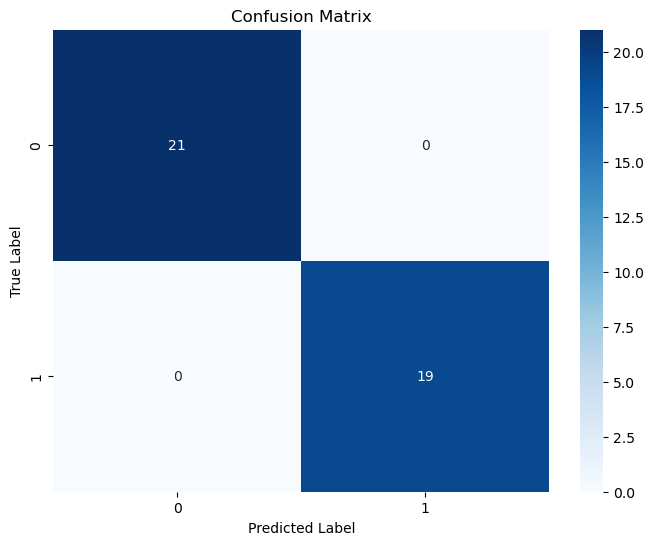

In [9]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

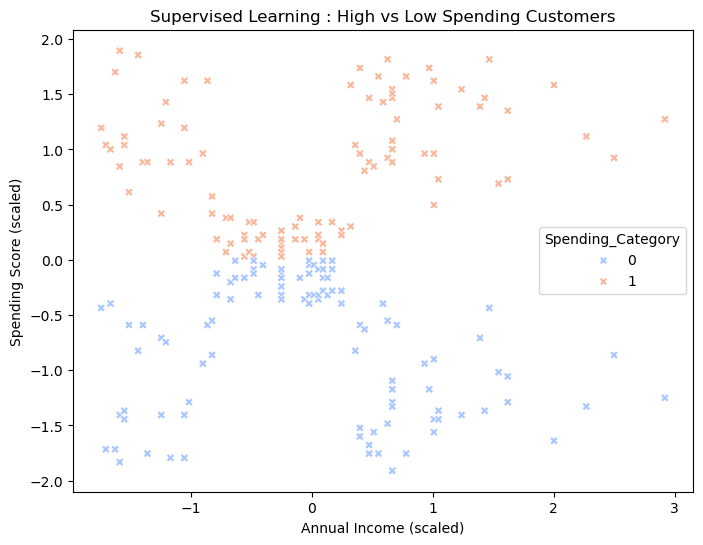

In [10]:
# Plot data 

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_scaled[:, 0],
    y=X_scaled[:, 1],
    hue=y,
    palette="coolwarm",
    marker="X"
)
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("Supervised Learning : High vs Low Spending Customers")
plt.show()

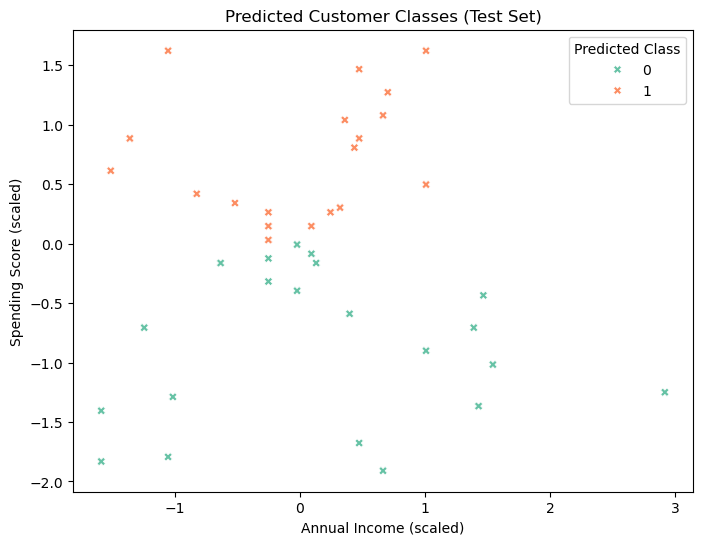

In [11]:
# Plot predictions

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_test[:, 0],
    y=X_test[:, 1],
    hue=y_pred,
    palette="Set2",
    marker="X"
)

plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("Predicted Customer Classes (Test Set)")
plt.legend(title="Predicted Class")
plt.show()

---
### Part 2 - Unsupervised Learning

---

In [12]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Spending_Category
0,1,Male,19,15,39,0
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,0


In [13]:
# Feature selection for K-Means clustering
X_cluster = df[["Annual Income (k$)", "Spending Score (1-100)"]]

# Feature scaling 
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

In [15]:
# Add elbow method logic

wcss = [] # within cluster sum of squares

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_SEED)
    kmeans.fit(X_cluster_scaled)
    wcss.append(kmeans.inertia_)

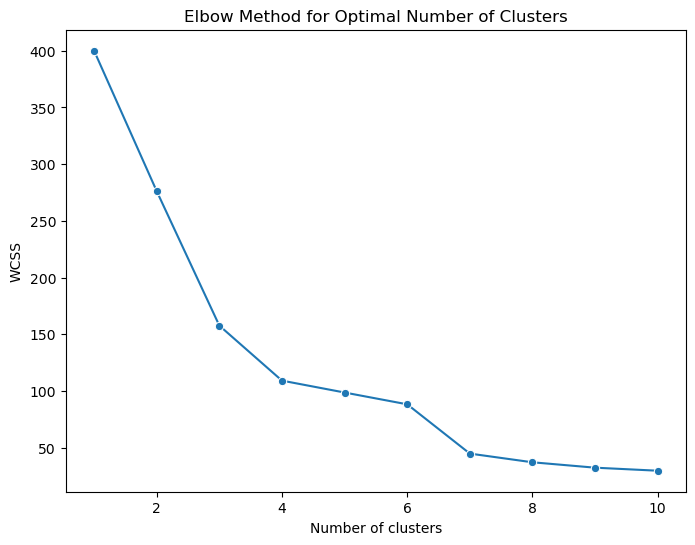

In [17]:
# Elbow method plot
plt.figure(figsize=(8,6))
sns.lineplot(x=range(1,11), y=wcss, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.show()

In [18]:
# Train K-Means Model
kmeans = KMeans(n_clusters=5, random_state=RANDOM_SEED)
clusters = kmeans.fit_predict(X_cluster_scaled)

df["cluster"] = clusters

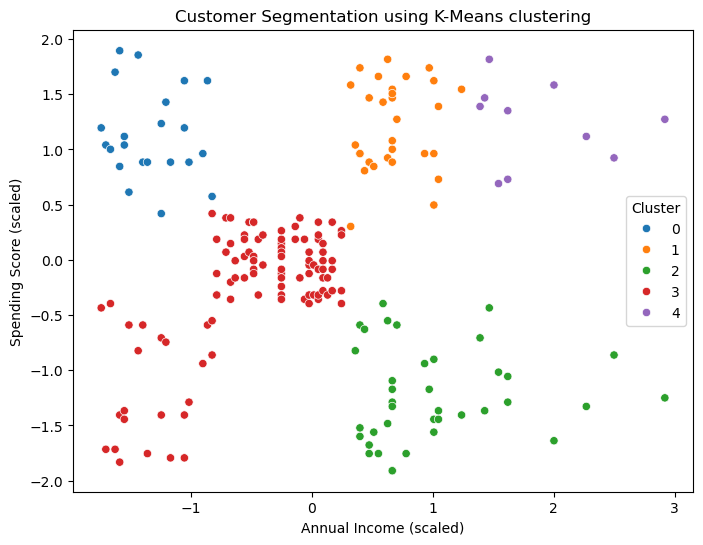

In [20]:
# Cluster Visualization
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_cluster_scaled[:, 0],
    y=X_cluster_scaled[:, 1],
    hue=clusters,
    palette="tab10"
)

plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("Customer Segmentation using K-Means clustering")
plt.legend(title="Cluster")
plt.show()

In [23]:
# Cluster Interpretation
df.groupby('cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Annual Income (k$),Spending Score (1-100)
cluster,,
0,25.727273,79.363636
1,78.233333,81.366667
2,87.000000,18.631579
3,47.960000,43.250000
4,109.700000,82.000000


In [25]:
# Silhouette Score
from sklearn.metrics import silhouette_score

score = silhouette_score(X_cluster_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.46201566980945685
